# Financial Ratio Comparison Tool for Listed Retail Companies
This peoject develops an interactive financial ratio comparison tool for listed retail companies. Using annual financial statement data from WRDS, the projcet compares selected firms across four key financial dimensions: profitability, liquidity, leverage, and efficiency. The final output is designed as a Streamlit-based interactive tool for accounting students and beginner users who want to compare company performance more clearly and efficiently.

## 1. Project Overiew

### 1.1 Background
Financial ratios are widely used in accounting and financial analysis to evaluate company performance. However, comparing companies using only one single ratio often leads to an incomplete understanding. A more balanced comparison should consider multiple dimensions, including profitability, liquidity, leverage, and efficiency. This project aims to address this issue by building a simple interactive tool that allows users to compare selected retail companies using a small set rey accounting ratios.

### 1.2 Project Objective
The objective of this project is to build an interactive financial ratio comparison tool for listed retail companies. The tool is intended to help users compare company performance over time and across firms using annual financial statement data. The project also demonstrates a complete Python workflow, including data extraction, cleaning, ratio calculation, visualization, and product-oriented output design.

## 2. Analytical Problem and Target Users

### 2.1 Analytical Problem
The main analytical problem addressed in this project is: How do selected retail companies differ in profitability, liquidity, leverage, and efficiency over time?
This question is important because financial performance cannot be fully understood through one metric alone. By comparing several accounting ratios together, users can obtain a more balanced view of how firms perform across multiple dimensions.

### 2.2 Target Users
The target users of this project are accounting students, finance beginners, and other users who want to compare company financial performance in a simple and interactive way. These users may not always be comfortable reading raw financial statements directly, so a ratio-based comparison tool can make the information easier to understand and interpret.

### 2.3 User Value
The value of this tool lies in its ability to transform raw company financial data into a more accessible comparison framework. Instead of manually calculating and interpreting several financial ratios, users can interactively select companies and review ratio trends, latest-year comparisons, and summary insights in one place.

## 3. Data Source and Company Selection

### 3.1 Data Source
The dataset used in this project is obtained from WRDS. WRDS was selected because it provides structured and reliable company financial statement data that are suitable for educational analysis. The project uses annual financial statement variables required for ratio calculation. The data access date should be clearly recorded for transparency and reproducibility.

### 3.2 Industry Selection
The retail industry was selected for this project because firms within the same industry are generally more comparable than firms across different industries. Retail companies often show meaningful differences in profitability, liquidity, leverage, and efficiency, which makes ratio analysis more informative and easier to interpret. In addition, ratio comparison within one industry helps reduce distortion caused by major business-model differences.

### 3.3 Candidate Companies
This project originally considered a broader candidate pool of listed retail companies. However, after the WRDS extraction and final data screening process, the final analytical sample consisted of nine companies: Best Buy, Costco, Dollar General, Dollar Tree, Home Depot, Kroger, Ross Stores, Target, and Walmart. These firms were retained because they had usable annual financial statement data over the selected time period and provided sufficient variation for financial ratio comparison within the retail industry.

### 3.4 Time Period
The analysis covers the period from 2016 to 2025. This time range is long enough to support trend analysis while remaining focused and manageable for a small interactive data product. It also allows users to observe whether the financial performance of selected firms is stable or changing over time.

## 4. Variables and Ratio Definitions

### 4.1 Raw Financial Variables
To calculate the selected accounting ratios, the project retains a limited set of raw financial variables from the annual financial statement data. These variables include revenue, net income, total assets, current assets, current liabilities, total liabilities, and shareholders' equity. Company name and fiscal year are also retained to support cross-company and time-series comparison.

### 4.2 Variable Description Table
The table below summarises the main variables used in this project.

| Variable | Meaning | Used for |
|---|---|---|
| company | Company name | Identification and comparison |
| fiscal_year | Fiscal year | Time-series analysis |
| revenue | Total sales/revenue | Net Profit Margin, Asset Turnover |
| net_income | Net income after tax | ROA, Net Profit Margin |
| total_assets | Total assets | ROA, Asset Turnover |
| current_assets | Current assets | Current Ratio |
| current_liabilities | Current liabilities | Current Ratio |
| total_liabilities | Total liabilities | Debt-to-Equity |
| shareholders_equity | Shareholders’ equity | Debt-to-Equity |

### 4.3 Selected Financial Ratios
This project uses five key accounting ratios to compare the selected companies. These ratios were selected because together they cover four important dimensions of company performance: profitability, liquidity, leverage, and efficiency. Using several ratios instead of one single ratio makes the comparison more balanced and informative.

### 4.4 Ratio Formula Table
The table below presents the financial ratios used in this project, together with their formulas and interpretations.

| Ratio | Formula | Interpretation |
|---|---|---|
| ROA | Net Income / Total Assets | Measures profitability relative to assets |
| Net Profit Margin | Net Income / Revenue | Measures profit generated from sales |
| Current Ratio | Current Assets / Current Liabilities | Measures short-term liquidity |
| Debt-to-Equity Ratio | Total Liabilities / Shareholders’ Equity | Measures leverage and financing risk |
| Asset Turnover | Revenue / Total Assets | Measures asset-use efficiency |

## 5. Data Extraction

### 5.1 Extracting Data from WRDS
The first technical step of the project is to extract the required annual financial statement data from WRDS. Only variables needed for ratio calculation and company identification are selected. This approach helps keep the workflow focused and avoids unnecessary complexity in the later stages of analysis.

In [4]:
import pandas as pd
import numpy as np
import wrds
import warnings

warnings.filterwarnings("ignore")

In [5]:
db = wrds.Connection()

Enter your WRDS username [joy]: jiayi24
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [6]:
def get_candidate_companies():
    """
    Return the full candidate pool of listed retail companies used in this project.
    """
    return [
        "WALMART INC",
        "COSTCO WHOLESALE CORP",
        "TARGET CORP",
        "KROGER CO",
        "BEST BUY CO INC",
        "HOME DEPOT INC",
        "DOLLAR GENERAL CORP",
        "DOLLAR TREE INC",
        "ROSS STORES INC"
    ]


def extract_wrds_data(company_list, start_year=2016, end_year=2025):
    """
    Extract annual financial statement data for the selected companies
    from WRDS Compustat Fundamentals Annual.
    """
    sql = f"""
    select
        gvkey,
        conm,
        fyear,
        datadate,
        sale,
        ni,
        at,
        act,
        lct,
        lt,
        seq
    from comp.funda
    where indfmt = 'INDL'
      and datafmt = 'STD'
      and popsrc = 'D'
      and consol = 'C'
      and fyear between {start_year} and {end_year}
      and conm in ({",".join([f"'{c}'" for c in company_list])})
    order by conm, fyear
    """

    raw_df = db.raw_sql(sql, date_cols=["datadate"])

    raw_df = raw_df.rename(columns={
        "conm": "company",
        "fyear": "fiscal_year",
        "sale": "revenue",
        "ni": "net_income",
        "at": "total_assets",
        "act": "current_assets",
        "lct": "current_liabilities",
        "lt": "total_liabilities",
        "seq": "shareholders_equity"
    })

    return raw_df

In [7]:
company_list = get_candidate_companies()
raw_df = extract_wrds_data(company_list, start_year=2016, end_year=2025)

raw_df.head()

,gvkey,company,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity
0,002184,BEST BUY CO INC,2016,2017-01-31,39403.0,1228.0,13856.0,10516.0,7122.0,9147.0,4709.0
1,002184,BEST BUY CO INC,2017,2018-01-31,42151.0,1000.0,13049.0,9829.0,7817.0,9437.0,3612.0
2,002184,BEST BUY CO INC,2018,2019-01-31,42879.0,1464.0,12901.0,8870.0,7513.0,9595.0,3306.0
3,002184,BEST BUY CO INC,2019,2020-01-31,43638.0,1541.0,15591.0,8857.0,8060.0,12112.0,3479.0
4,002184,BEST BUY CO INC,2020,2021-01-31,47262.0,1798.0,19067.0,12540.0,10521.0,14480.0,4587.0


### 5.2 Filtering Companies and Years
After the initial extraction, the dataset is filtered to keep only the selected retail companies and the target time period from 2016 to 2025. This step ensures that the analysis remains aligned with the project objective and that all observations are relevant to the planned comparison tool.

In [8]:
df = raw_df.copy()

selected_companies = get_candidate_companies()

start_year = 2016
end_year = 2025

df = df[
    (df["company"].isin(selected_companies)) &
    (df["fiscal_year"] >= start_year) &
    (df["fiscal_year"] <= end_year)
].copy()

print("Companies in dataset:")
print(df["company"].unique())

print("\nFiscal years in dataset:")
print(df["fiscal_year"].unique())

print("\nNumber of observations by company:")
print(df["company"].value_counts().sort_index())

print("\nDataset shape:")
print(df.shape)

Companies in dataset:
<StringArray>
[      'BEST BUY CO INC', 'COSTCO WHOLESALE CORP',   'DOLLAR GENERAL CORP',
       'DOLLAR TREE INC',        'HOME DEPOT INC',             'KROGER CO',
       'ROSS STORES INC',           'TARGET CORP',           'WALMART INC']
Length: 9, dtype: string

Fiscal years in dataset:
<IntegerArray>
[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Length: 10, dtype: Int64

Number of observations by company:
company
BEST BUY CO INC          10
COSTCO WHOLESALE CORP    10
DOLLAR GENERAL CORP      10
DOLLAR TREE INC          10
HOME DEPOT INC           10
KROGER CO                10
ROSS STORES INC          10
TARGET CORP              10
WALMART INC              10
Name: count, dtype: Int64

Dataset shape:
(90, 11)


### 5.3 Initial Data Preview
Before cleaning and transformation, the extracted dataset is previewed to check its structure, variable types, and general completeness. This step is useful for identifying possible issues such as missing values, inconsistent company labels, or unexpected data formats.

In [9]:
# Display the size of the filtered dataset
# The output shows the number of rows and columns
print("Dataset shape:")
print(df.shape)

# Preview the first five rows of the dataset
# This helps check whether the extracted variables and sample look correct
print("\nFirst 5 rows:")
df.head()

Dataset shape:
(90, 11)

First 5 rows:


,gvkey,company,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity
0,002184,BEST BUY CO INC,2016,2017-01-31,39403.0,1228.0,13856.0,10516.0,7122.0,9147.0,4709.0
1,002184,BEST BUY CO INC,2017,2018-01-31,42151.0,1000.0,13049.0,9829.0,7817.0,9437.0,3612.0
2,002184,BEST BUY CO INC,2018,2019-01-31,42879.0,1464.0,12901.0,8870.0,7513.0,9595.0,3306.0
3,002184,BEST BUY CO INC,2019,2020-01-31,43638.0,1541.0,15591.0,8857.0,8060.0,12112.0,3479.0
4,002184,BEST BUY CO INC,2020,2021-01-31,47262.0,1798.0,19067.0,12540.0,10521.0,14480.0,4587.0


In [10]:
# Check the overall structure of the dataset
# This shows column names, non-missing counts, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   gvkey                90 non-null     string        
 1   company              90 non-null     string        
 2   fiscal_year          90 non-null     Int64         
 3   datadate             90 non-null     datetime64[ns]
 4   revenue              90 non-null     Float64       
 5   net_income           90 non-null     Float64       
 6   total_assets         90 non-null     Float64       
 7   current_assets       90 non-null     Float64       
 8   current_liabilities  90 non-null     Float64       
 9   total_liabilities    90 non-null     Float64       
 10  shareholders_equity  90 non-null     Float64       
dtypes: Float64(7), Int64(1), datetime64[ns](1), string(2)
memory usage: 8.6 KB


In [11]:
# Check the number of missing values in each column
# This helps identify whether any variables need cleaning before ratio calculation
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
gvkey                  0
company                0
fiscal_year            0
datadate               0
revenue                0
net_income             0
total_assets           0
current_assets         0
current_liabilities    0
total_liabilities      0
shareholders_equity    0
dtype: int64


In [12]:
# Display summary statistics for the numerical variables
# This helps check the scale and distribution of the financial data
df.describe()

,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity
count,90.0,90,90.0,90.0,90.0,90.0,90.0,90.0,90.0
mean,2020.5,2021-07-15 07:12:00,138455.1842,4756.613633,58432.030789,20242.4956,21144.337567,41657.825211,16061.272244
min,2016.0,2016-08-31 00:00:00,12531.565,-3030.1,5309.351,2813.049,1752.506,2561.334,-3116.0
25%,2018.0,2019-01-31 00:00:00,28899.725,1518.97325,15726.95,7489.556,5048.08075,12008.5,4117.18325
50%,2020.5,2021-05-17 00:00:00,94078.0,2407.6105,37774.5,12338.5,14220.0,28761.0,7056.65
75%,2023.0,2024-01-31 00:00:00,149593.75,6575.5,57215.75,23007.0,21948.0,43831.75,12809.5
max,2025.0,2026-01-31 00:00:00,710813.0,21893.0,284668.0,90067.0,107469.0,178488.0,99617.0
std,2.888373,NaN,169596.006936,5262.499023,68371.885027,21014.950919,25242.522354,43975.996339,24159.832914


## 6. Data Cleaning and Preparation

### 6.1 Selecting Relevant Columns
To simplify the workflow, only the variables required for ratio calculation and comparison are retained. Removing unnecessary columns improves readability and makes the later stages of processing more efficient.

In [13]:
# Keep only the variables required for later ratio calculation and comparison
# This makes the dataset more focused and easier to use in the cleaning stage
df = df[[
    "gvkey",
    "company",
    "fiscal_year",
    "datadate",
    "revenue",
    "net_income",
    "total_assets",
    "current_assets",
    "current_liabilities",
    "total_liabilities",
    "shareholders_equity"
]].copy()

# Preview the first five rows after selecting the relevant columns
df.head()

,gvkey,company,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity
0,002184,BEST BUY CO INC,2016,2017-01-31,39403.0,1228.0,13856.0,10516.0,7122.0,9147.0,4709.0
1,002184,BEST BUY CO INC,2017,2018-01-31,42151.0,1000.0,13049.0,9829.0,7817.0,9437.0,3612.0
2,002184,BEST BUY CO INC,2018,2019-01-31,42879.0,1464.0,12901.0,8870.0,7513.0,9595.0,3306.0
3,002184,BEST BUY CO INC,2019,2020-01-31,43638.0,1541.0,15591.0,8857.0,8060.0,12112.0,3479.0
4,002184,BEST BUY CO INC,2020,2021-01-31,47262.0,1798.0,19067.0,12540.0,10521.0,14480.0,4587.0


### 6.2 Handling Missing Values
Missing values are checked to ensure that ratio calculations are based on valid observations. If a required variable is missing for a given company-year observation, the corresponding ratio may not be calculated. This step helps avoid misleading results and improves the reliability of the analysis.

In [14]:
# Check the number of missing values in each column before cleaning
# This helps identify whether any key financial variables are incomplete
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
gvkey                  0
company                0
fiscal_year            0
datadate               0
revenue                0
net_income             0
total_assets           0
current_assets         0
current_liabilities    0
total_liabilities      0
shareholders_equity    0
dtype: int64


In [15]:
# Define the key financial variables required for later ratio calculation
required_cols = [
    "revenue",
    "net_income",
    "total_assets",
    "current_assets",
    "current_liabilities",
    "total_liabilities",
    "shareholders_equity"
]

# Remove observations with missing values in the required variables
# This ensures that the later ratio calculations are based on complete data
df = df.dropna(subset=required_cols).copy()

# Check missing values again after cleaning
print("Missing values after cleaning:")
print(df.isnull().sum())

# Check the size of the dataset after removing incomplete observations
print("\nDataset shape after dropping missing values:")
print(df.shape)

Missing values after cleaning:
gvkey                  0
company                0
fiscal_year            0
datadate               0
revenue                0
net_income             0
total_assets           0
current_assets         0
current_liabilities    0
total_liabilities      0
shareholders_equity    0
dtype: int64

Dataset shape after dropping missing values:
(90, 11)


### 6.3 Validity Checks for Ratio Calculation
Before calculating the financial ratios, denominator values are checked to avoid division by zero or invalid calculations. For example, total assets, current liabilities, and shareholders’ equity must be valid and non-zero when used in ratio formulas. This step is necessary to ensure technical correctness.

In [16]:
# Check whether any denominator variables contain zero values
# This is important because later ratio calculations involve division
print("Rows with zero revenue:", (df["revenue"] == 0).sum())
print("Rows with zero total_assets:", (df["total_assets"] == 0).sum())
print("Rows with zero current_liabilities:", (df["current_liabilities"] == 0).sum())
print("Rows with zero shareholders_equity:", (df["shareholders_equity"] == 0).sum())

Rows with zero revenue: 0
Rows with zero total_assets: 0
Rows with zero current_liabilities: 0
Rows with zero shareholders_equity: 0


In [17]:
# Remove observations with zero values in key denominator variables
# This ensures that later ratio calculations do not involve division by zero
df = df[
    (df["revenue"] != 0) &
    (df["total_assets"] != 0) &
    (df["current_liabilities"] != 0) &
    (df["shareholders_equity"] != 0)
].copy()

# Check the dataset size after denominator validity checks
print("Dataset shape after denominator checks:")
print(df.shape)

Dataset shape after denominator checks:
(90, 11)


### 6.4 Preparing the Final Cleaned Dataset
After filtering and cleaning, the dataset is transformed into a final company-year panel that is ready for ratio calculation. At this stage, the dataset includes only the selected companies, years, and valid financial statement variables needed for the analysis.

In [18]:
# Sort the cleaned dataset by company and fiscal year
# Reset the index to create a clean and orderly DataFrame
df = df.sort_values(["company", "fiscal_year"]).reset_index(drop=True)

# Preview the first five rows after sorting
df.head()

,gvkey,company,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity
0,002184,BEST BUY CO INC,2016,2017-01-31,39403.0,1228.0,13856.0,10516.0,7122.0,9147.0,4709.0
1,002184,BEST BUY CO INC,2017,2018-01-31,42151.0,1000.0,13049.0,9829.0,7817.0,9437.0,3612.0
2,002184,BEST BUY CO INC,2018,2019-01-31,42879.0,1464.0,12901.0,8870.0,7513.0,9595.0,3306.0
3,002184,BEST BUY CO INC,2019,2020-01-31,43638.0,1541.0,15591.0,8857.0,8060.0,12112.0,3479.0
4,002184,BEST BUY CO INC,2020,2021-01-31,47262.0,1798.0,19067.0,12540.0,10521.0,14480.0,4587.0


## 7. Ratio Calculation

### 7.1 Calculating Profitability Ratios
The first group of ratios measures profitability. ROA is used to evaluate how effectively a company uses its assets to generate profit, while net profit margin shows how much net profit is earned from each unit of revenue. These two ratios together provide a broader view of profit performance.

In [19]:
df["roa"] = df["net_income"] / df["total_assets"]
df["net_profit_margin"] = df["net_income"] / df["revenue"]

df[["company", "fiscal_year", "roa", "net_profit_margin"]].head()

,company,fiscal_year,roa,net_profit_margin
0,BEST BUY CO INC,2016,0.088626,0.031165
1,BEST BUY CO INC,2017,0.076634,0.023724
2,BEST BUY CO INC,2018,0.11348,0.034143
3,BEST BUY CO INC,2019,0.098839,0.035313
4,BEST BUY CO INC,2020,0.094299,0.038043


### 7.2 Calculating Liquidity Ratio
The current ratio is used to measure short-term liquidity. It indicates whether a company has sufficient current assets to cover its current liabilities. This ratio is useful for comparing short-term financial flexibility across firms.

In [20]:
df["current_ratio"] = df["current_assets"] / df["current_liabilities"]

df[["company", "fiscal_year", "current_ratio"]].head()

,company,fiscal_year,current_ratio
0,BEST BUY CO INC,2016,1.476552
1,BEST BUY CO INC,2017,1.257388
2,BEST BUY CO INC,2018,1.18062
3,BEST BUY CO INC,2019,1.098883
4,BEST BUY CO INC,2020,1.191902


### 7.3 Calculating Leverage Ratio
The debt-to-equity ratio is used to measure leverage. It reflects the extent to which a company relies on liabilities relative to shareholders’ equity. A higher value generally suggests a greater dependence on debt financing and potentially higher financial risk.

In [21]:
df["debt_to_equity"] = df["total_liabilities"] / df["shareholders_equity"]

df[["company", "fiscal_year", "debt_to_equity"]].head()

,company,fiscal_year,debt_to_equity
0,BEST BUY CO INC,2016,1.942451
1,BEST BUY CO INC,2017,2.61268
2,BEST BUY CO INC,2018,2.902299
3,BEST BUY CO INC,2019,3.48146
4,BEST BUY CO INC,2020,3.156747


### 7.4 Calculating Efficiency Ratio
Asset turnover is used to evaluate how efficiently a company uses its assets to generate revenue. This ratio is especially meaningful in the retail industry, where sales generation and asset utilization are important aspects of business performance.

In [22]:
df["asset_turnover"] = df["revenue"] / df["total_assets"]

df[["company", "fiscal_year", "asset_turnover"]].head()

,company,fiscal_year,asset_turnover
0,BEST BUY CO INC,2016,2.84375
1,BEST BUY CO INC,2017,3.230209
2,BEST BUY CO INC,2018,3.323696
3,BEST BUY CO INC,2019,2.798922
4,BEST BUY CO INC,2020,2.478733


### 7.5 Final Ratio Dataset
After all five ratios are calculated, the resulting dataset contains both the raw financial variables and the newly created ratio variables. This ratio-level dataset forms the basis for the visual analysis and for the final Streamlit tool.


In [23]:
# Create a final ratio-level dataset for later analysis and visualization
df_ratio = df.copy()

# Preview the first five rows of the final ratio dataset
df_ratio.head()

,gvkey,company,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
0,002184,BEST BUY CO INC,2016,2017-01-31,39403.0,1228.0,13856.0,10516.0,7122.0,9147.0,4709.0,0.088626,0.031165,1.476552,1.942451,2.84375
1,002184,BEST BUY CO INC,2017,2018-01-31,42151.0,1000.0,13049.0,9829.0,7817.0,9437.0,3612.0,0.076634,0.023724,1.257388,2.61268,3.230209
2,002184,BEST BUY CO INC,2018,2019-01-31,42879.0,1464.0,12901.0,8870.0,7513.0,9595.0,3306.0,0.11348,0.034143,1.18062,2.902299,3.323696
3,002184,BEST BUY CO INC,2019,2020-01-31,43638.0,1541.0,15591.0,8857.0,8060.0,12112.0,3479.0,0.098839,0.035313,1.098883,3.48146,2.798922
4,002184,BEST BUY CO INC,2020,2021-01-31,47262.0,1798.0,19067.0,12540.0,10521.0,14480.0,4587.0,0.094299,0.038043,1.191902,3.156747,2.478733


In [24]:
# Define the ratio columns in the final dataset
ratio_cols = ["roa", "net_profit_margin", "current_ratio", "debt_to_equity", "asset_turnover"]

# Round the ratio values to four decimal places for cleaner presentation
df_ratio[ratio_cols] = df_ratio[ratio_cols].round(4)

# Preview the first five rows after formatting the ratio columns
df_ratio.head()

,gvkey,company,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
0,002184,BEST BUY CO INC,2016,2017-01-31,39403.0,1228.0,13856.0,10516.0,7122.0,9147.0,4709.0,0.0886,0.0312,1.4766,1.9425,2.8438
1,002184,BEST BUY CO INC,2017,2018-01-31,42151.0,1000.0,13049.0,9829.0,7817.0,9437.0,3612.0,0.0766,0.0237,1.2574,2.6127,3.2302
2,002184,BEST BUY CO INC,2018,2019-01-31,42879.0,1464.0,12901.0,8870.0,7513.0,9595.0,3306.0,0.1135,0.0341,1.1806,2.9023,3.3237
3,002184,BEST BUY CO INC,2019,2020-01-31,43638.0,1541.0,15591.0,8857.0,8060.0,12112.0,3479.0,0.0988,0.0353,1.0989,3.4815,2.7989
4,002184,BEST BUY CO INC,2020,2021-01-31,47262.0,1798.0,19067.0,12540.0,10521.0,14480.0,4587.0,0.0943,0.038,1.1919,3.1567,2.4787


## 8. Exploratory Data Analysis

### 8.1 Dataset Overiew
The cleaned dataset is first examined at a general level to confirm the number of firms, years, and observations included in the analysis. This step helps ensure that the final dataset matches the intended project scope.

In [25]:
# Check how many companies are included in the final ratio dataset
print("Number of companies:", df_ratio["company"].nunique())

# Display the company names included in the dataset
print("Companies:", df_ratio["company"].unique())

# Check the fiscal year range covered by the dataset
print("\nYear range:", df_ratio["fiscal_year"].min(), "to", df_ratio["fiscal_year"].max())

# Display the overall size of the final ratio dataset
print("Dataset shape:", df_ratio.shape)

Number of companies: 9
Companies: <StringArray>
[      'BEST BUY CO INC', 'COSTCO WHOLESALE CORP',   'DOLLAR GENERAL CORP',
       'DOLLAR TREE INC',        'HOME DEPOT INC',             'KROGER CO',
       'ROSS STORES INC',           'TARGET CORP',           'WALMART INC']
Length: 9, dtype: string

Year range: 2016 to 2025
Dataset shape: (90, 16)


### 8.2 Descriptive Statistics
Descriptive statistics are used to summarise the main features of the ratio dataset. These summaries provide an initial understanding of the scale, distribution, and variation of the selected financial ratios before detailed visual comparison is conducted.

In [26]:
df_ratio[["roa", "net_profit_margin", "current_ratio", "debt_to_equity", "asset_turnover"]].describe()

,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
count,90.0,90.0,90.0,90.0,90.0
mean,0.090203,0.042984,1.138569,3.611107,2.236888
std,0.06696,0.040225,0.304077,11.31993,0.746862
min,-0.1625,-0.1724,0.735,-43.3797,0.9429
25%,0.056125,0.024,0.93705,1.820075,1.590125
50%,0.07675,0.03535,1.0607,2.38255,2.2032
75%,0.1133,0.065975,1.283325,3.73325,2.833775
max,0.2614,0.1087,2.0486,72.3046,3.6438


### 8.3 Preliminary Observations
The exploratory stage also helps identify broad patterns in the data. For example, some companies may appear to have stronger profitability, while others may show higher liquidity or greater leverage. These preliminary observations provide a useful starting point for later interpretation.

In [27]:
# Group the final ratio dataset by company
# Calculate the average value of each selected ratio for each firm
company_summary = df_ratio.groupby("company")[[
    "roa",
    "net_profit_margin",
    "current_ratio",
    "debt_to_equity",
    "asset_turnover"
]].mean().round(4)

# Display the company-level average ratio summary
company_summary

,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
company,,,,,
BEST BUY CO INC,0.092,0.0317,1.1305,3.5662,2.9117
COSTCO WHOLESALE CORP,0.0851,0.0246,1.022,2.0013,3.4531
DOLLAR GENERAL CORP,0.0841,0.0565,1.2588,2.54,1.4762
DOLLAR TREE INC,0.017,0.0107,1.4361,2.028,1.3027
HOME DEPOT INC,0.1972,0.0967,1.1775,11.4606,2.0333
KROGER CO,0.0469,0.0158,0.7969,4.5275,2.958
ROSS STORES INC,0.1543,0.0857,1.6532,1.6936,1.7148
TARGET CORP,0.077,0.0411,0.9342,2.8251,1.8739
WALMART INC,0.058,0.0241,0.838,1.8576,2.4084


## 9. Visual Comparison of Financial Ratios

### 9.1 Ratio Trends Over Time
Trend charts are used to compare how each selected ratio changes over time for the chosen companies. This time-series perspective makes it easier to identify stable performers, changing patterns, or differences in financial structure across firms.

In [28]:
import matplotlib.pyplot as plt

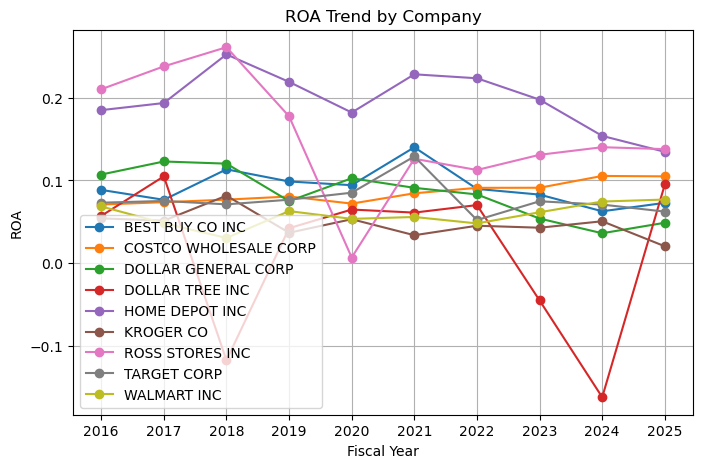

In [30]:
plt.figure(figsize=(8, 5))
for company in df_ratio["company"].unique():
    temp = df_ratio[df_ratio["company"] == company]
    plt.plot(temp["fiscal_year"], temp["roa"], marker="o", label=company)

years = sorted(df_ratio["fiscal_year"].unique())
plt.xticks(years, [str(int(y)) for y in years])

plt.title("ROA Trend by Company")
plt.xlabel("Fiscal Year")
plt.ylabel("ROA")
plt.legend()
plt.grid(True)
plt.show()

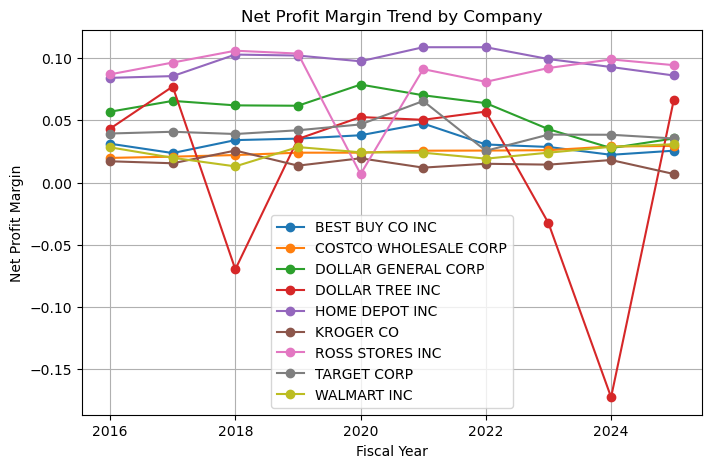

In [31]:
plt.figure(figsize=(8, 5))
for company in df_ratio["company"].unique():
    temp = df_ratio[df_ratio["company"] == company]
    plt.plot(temp["fiscal_year"], temp["net_profit_margin"], marker="o", label=company)

plt.title("Net Profit Margin Trend by Company")
plt.xlabel("Fiscal Year")
plt.ylabel("Net Profit Margin")
plt.legend()
plt.grid(True)
plt.show()

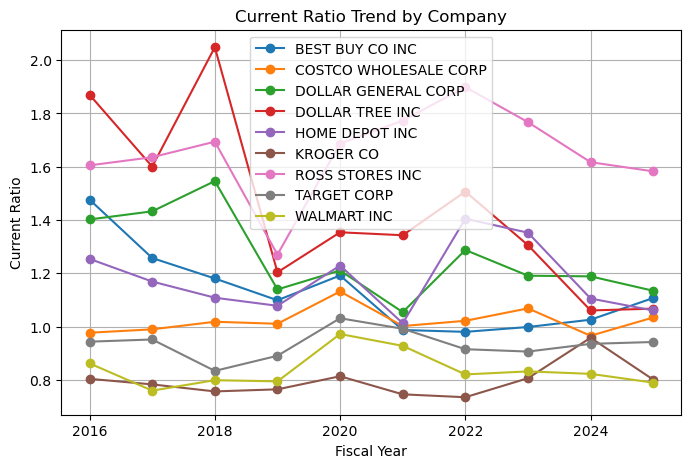

In [32]:
plt.figure(figsize=(8, 5))
for company in df_ratio["company"].unique():
    temp = df_ratio[df_ratio["company"] == company]
    plt.plot(temp["fiscal_year"], temp["current_ratio"], marker="o", label=company)

plt.title("Current Ratio Trend by Company")
plt.xlabel("Fiscal Year")
plt.ylabel("Current Ratio")
plt.legend()
plt.grid(True)
plt.show()

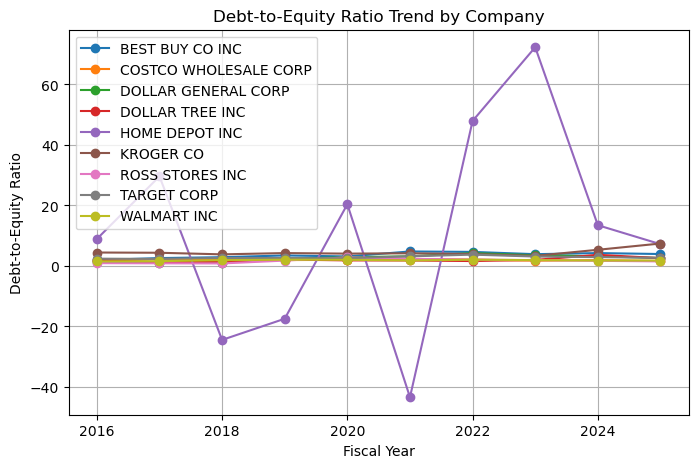

In [33]:
plt.figure(figsize=(8, 5))
for company in df_ratio["company"].unique():
    temp = df_ratio[df_ratio["company"] == company]
    plt.plot(temp["fiscal_year"], temp["debt_to_equity"], marker="o", label=company)

plt.title("Debt-to-Equity Ratio Trend by Company")
plt.xlabel("Fiscal Year")
plt.ylabel("Debt-to-Equity Ratio")
plt.legend()
plt.grid(True)
plt.show()

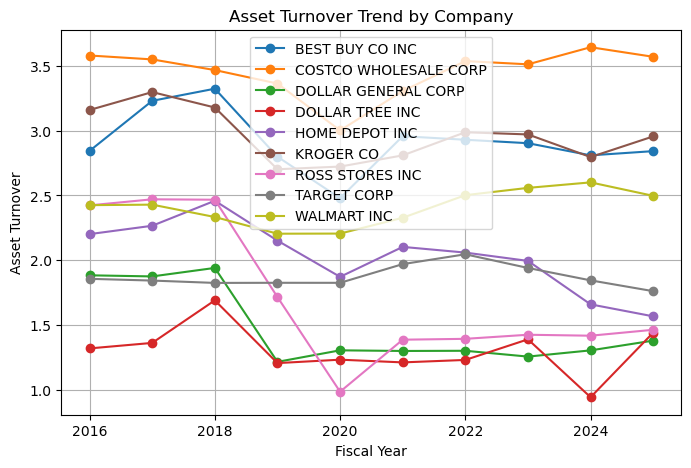

In [34]:
plt.figure(figsize=(8, 5))
for company in df_ratio["company"].unique():
    temp = df_ratio[df_ratio["company"] == company]
    plt.plot(temp["fiscal_year"], temp["asset_turnover"], marker="o", label=company)

plt.title("Asset Turnover Trend by Company")
plt.xlabel("Fiscal Year")
plt.ylabel("Asset Turnover")
plt.legend()
plt.grid(True)
plt.show()

### 9.2 Latest-Year Comparison
In addition to trend analysis, the project also compares the selected companies in the most recent year available within the chosen period. This provides a simpler snapshot of comparative performance and allows users to quickly identify which firms appear stronger or weaker in each ratio.

In [35]:
# Identify the most recent fiscal year in the final ratio dataset
latest_year = df_ratio["fiscal_year"].max()

# Keep only the observations from the latest year
latest_df = df_ratio[df_ratio["fiscal_year"] == latest_year].copy()

# Display the latest year and preview the filtered dataset
print("Latest year:", latest_year)
latest_df.head()

Latest year: 2025


,gvkey,company,fiscal_year,datadate,revenue,net_income,total_assets,current_assets,current_liabilities,total_liabilities,shareholders_equity,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
9,002184,BEST BUY CO INC,2025,2026-01-31,41691.0,1069.0,14670.0,8504.0,7679.0,11706.0,2964.0,0.0729,0.0256,1.1074,3.9494,2.8419
19,029028,COSTCO WHOLESALE CORP,2025,2025-08-31,275235.0,8099.0,77099.0,38380.0,37108.0,47935.0,29164.0,0.105,0.0294,1.0343,1.6436,3.5699
29,004016,DOLLAR GENERAL CORP,2025,2026-01-31,42724.369,1512.311,30963.73,7897.803,6961.135,22451.768,8511.962,0.0488,0.0354,1.1346,2.6377,1.3798
39,031587,DOLLAR TREE INC,2025,2026-01-31,19411.8,1282.5,13466.2,3446.2,3228.6,9711.3,3754.9,0.0952,0.0661,1.0674,2.5863,1.4415
49,005680,HOME DEPOT INC,2025,2026-01-31,164683.0,14156.0,105095.0,34391.0,32424.0,92282.0,12813.0,0.1347,0.086,1.0607,7.2022,1.567


In [36]:
latest_comparison = latest_df[[
    "company",
    "roa",
    "net_profit_margin",
    "current_ratio",
    "debt_to_equity",
    "asset_turnover"
]].round(4)

latest_comparison

,company,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
9,BEST BUY CO INC,0.0729,0.0256,1.1074,3.9494,2.8419
19,COSTCO WHOLESALE CORP,0.105,0.0294,1.0343,1.6436,3.5699
29,DOLLAR GENERAL CORP,0.0488,0.0354,1.1346,2.6377,1.3798
39,DOLLAR TREE INC,0.0952,0.0661,1.0674,2.5863,1.4415
49,HOME DEPOT INC,0.1347,0.086,1.0607,7.2022,1.567
59,KROGER CO,0.0203,0.0069,0.801,7.4265,2.9556
69,ROSS STORES INC,0.138,0.0943,1.5827,1.513,1.4632
79,TARGET CORP,0.0623,0.0354,0.9423,2.6802,1.7613
89,WALMART INC,0.0769,0.0308,0.7898,1.7917,2.497


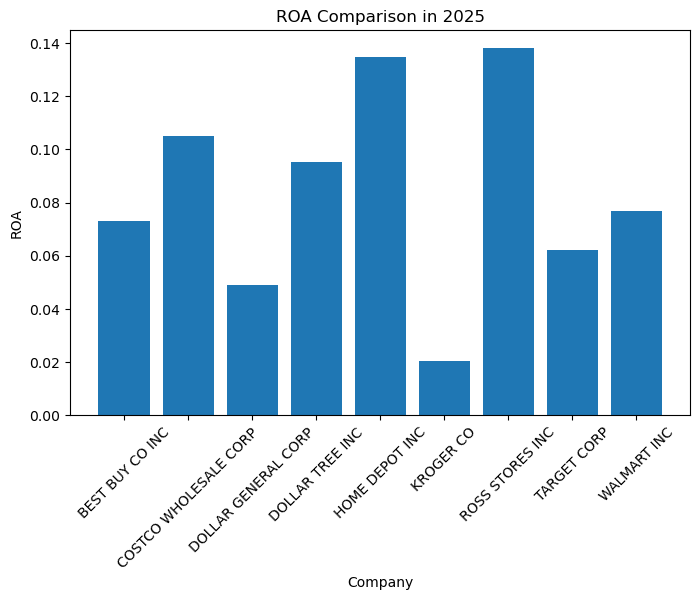

In [37]:
plt.figure(figsize=(8, 5))
plt.bar(latest_df["company"], latest_df["roa"])
plt.title(f"ROA Comparison in {latest_year}")
plt.xlabel("Company")
plt.ylabel("ROA")
plt.xticks(rotation=45)
plt.show()

### 9.3 Why Visualization Matters
Visualization is an important part of this project because raw financial numbers can be difficult to interpret directly. By converting the ratio dataset into charts and comparison tables, the project makes the analytical results more accessible and easier for users to understand.

## 10. Key Findings and Interpretation

In [38]:
# Rank the companies in the latest fiscal year across the five selected ratios
# The ranking is calculated in descending order, so larger values receive stronger ranks
# Note: debt-to-equity should be interpreted carefully, since a higher value does not necessarily mean better performance
latest_df.set_index("company")[[
    "roa",
    "net_profit_margin",
    "current_ratio",
    "debt_to_equity",
    "asset_turnover"
]].rank(ascending=False).round(2)

,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
company,,,,,
BEST BUY CO INC,6.0,8.0,3.0,3.0,3.0
COSTCO WHOLESALE CORP,3.0,7.0,6.0,8.0,1.0
DOLLAR GENERAL CORP,8.0,4.5,2.0,5.0,9.0
DOLLAR TREE INC,4.0,3.0,4.0,6.0,8.0
HOME DEPOT INC,2.0,2.0,5.0,2.0,6.0
KROGER CO,9.0,9.0,8.0,1.0,2.0
ROSS STORES INC,1.0,1.0,1.0,9.0,7.0
TARGET CORP,7.0,4.5,7.0,4.0,5.0
WALMART INC,5.0,6.0,9.0,7.0,4.0


In [39]:
# Group the final ratio dataset by company
# Calculate the average value of each selected ratio over the full sample period
average_ratios = df_ratio.groupby("company")[[
    "roa",
    "net_profit_margin",
    "current_ratio",
    "debt_to_equity",
    "asset_turnover"
]].mean().round(4)

# Display the multi-year average ratio summary for each company
average_ratios

,roa,net_profit_margin,current_ratio,debt_to_equity,asset_turnover
company,,,,,
BEST BUY CO INC,0.092,0.0317,1.1305,3.5662,2.9117
COSTCO WHOLESALE CORP,0.0851,0.0246,1.022,2.0013,3.4531
DOLLAR GENERAL CORP,0.0841,0.0565,1.2588,2.54,1.4762
DOLLAR TREE INC,0.017,0.0107,1.4361,2.028,1.3027
HOME DEPOT INC,0.1972,0.0967,1.1775,11.4606,2.0333
KROGER CO,0.0469,0.0158,0.7969,4.5275,2.958
ROSS STORES INC,0.1543,0.0857,1.6532,1.6936,1.7148
TARGET CORP,0.077,0.0411,0.9342,2.8251,1.8739
WALMART INC,0.058,0.0241,0.838,1.8576,2.4084


### 10.1 Profitability Findings
Across the full 2016–2025 period, Home Depot shows the strongest profitability overall. It records the highest average ROA at 0.1972 and the highest average net profit margin at 0.0967, which indicates consistently strong earnings relative to both assets and sales. Ross Stores is the second strongest profitability performer, with an average ROA of 0.1543 and an average net profit margin of 0.0857. These results suggest that both firms were able to convert revenue and assets into profit more effectively than the other selected retailers over the sample period.

At the weaker end of the sample, Dollar Tree and Kroger show the lowest long-run profitability. Dollar Tree records the lowest average ROA (0.0170) and the lowest average net profit margin (0.0107), while Kroger also reports relatively weak average profitability, especially in net profit margin (0.0158). The trend charts show that Dollar Tree’s profitability is highly volatile, with negative values in several years before a visible recovery in 2025. This means that its latest-year improvement should be interpreted cautiously rather than as evidence of consistently strong profitability.

The latest-year comparison for 2025 shows a slightly different pattern. In 2025, Ross Stores records the highest ROA (0.1380) and the highest net profit margin (0.0943), while Home Depot remains one of the strongest firms with ROA of 0.1347 and net profit margin of 0.0860. Therefore, Home Depot appears to be the strongest long-run profitability performer, while Ross Stores is the strongest profitability performer in the most recent year.

### 10.2 Liquidity Findings
Liquidity is measured using the current ratio. Over the full 2016–2025 period, Ross Stores shows the strongest liquidity position with an average current ratio of 1.6532, followed by Dollar Tree (1.4361) and Dollar General (1.2588). These values suggest that these firms generally maintained a stronger short-term asset buffer relative to short-term liabilities than the rest of the sample.

By contrast, Kroger, Walmart, and Target appear weaker in liquidity. Kroger records the lowest average current ratio (0.7969), while Walmart (0.8380) and Target (0.9342) also remain below 1 on average. This suggests that these firms operated with tighter short-term liquidity positions during the sample period. However, in a retail setting, a relatively low current ratio does not automatically imply poor performance, because some large retailers may deliberately operate with leaner working capital structures.

The 2025 results confirm Ross Stores’ strength in this area. Ross records the highest current ratio in the latest year at 1.5827, while Walmart (0.7898) and Kroger (0.8010) remain the weakest in the latest year as well. Overall, liquidity differences are clear in this sample, and Ross Stores stands out as the strongest firm on this dimension.

### 10.3 Leverage Findings
Leverage is measured using the debt-to-equity ratio, but this ratio must be interpreted carefully because a higher value does not indicate better performance. Instead, a lower debt-to-equity ratio generally suggests lower financial leverage and potentially lower balance-sheet risk.

On a multi-year average basis, Ross Stores appears to have the lowest leverage, with an average debt-to-equity ratio of 1.6936. Walmart (1.8576) and Costco (2.0013) also show relatively moderate leverage compared with the rest of the sample. These firms therefore appear more conservative in this dimension than companies such as Best Buy, Kroger, and especially Home Depot.

The most striking result is Home Depot, which records by far the highest average debt-to-equity ratio (11.4606) and shows very large fluctuations in the trend chart. Its leverage ratio becomes extremely volatile in several years, including both unusually high positive values and negative values, which suggests that changes in equity strongly affect the measure. For this reason, Home Depot’s debt-to-equity results should be interpreted cautiously rather than treated as a simple sign of weak or strong performance.

In the latest year, Ross Stores again records the lowest debt-to-equity ratio (1.5130), followed by Costco (1.6436) and Walmart (1.7917). By contrast, Kroger (7.4265) and Home Depot (7.2022) are the most highly leveraged firms in 2025. Overall, the leverage results suggest that Ross Stores, Costco, and Walmart maintain comparatively lower leverage, while Kroger and Home Depot rely more heavily on leveraged capital structures.

### 10.4 Efficiency Findings
Efficiency is measured using asset turnover, which shows how effectively firms generate revenue from their asset base. In this dimension, Costco is the clear leader. It records the highest average asset turnover in the sample at 3.4531, and the trend chart shows that this strength is highly consistent across the full 2016–2025 period. This indicates that Costco is especially effective at generating sales from its assets.

Kroger (2.9580) and Best Buy (2.9117) also perform strongly in asset turnover on a multi-year basis. Walmart remains solid as well, with an average asset turnover of 2.4084. By contrast, Dollar Tree (1.3027) and Dollar General (1.4762) show the weakest efficiency results, suggesting that their sales generation relative to total assets is more limited than that of the stronger firms in the sample.

The latest-year comparison confirms this general pattern. In 2025, Costco again records the highest asset turnover at 3.5699, followed by Kroger (2.9556) and Best Buy (2.8419). This consistency strengthens the conclusion that Costco is the most efficient firm in the final sample, while Dollar Tree and Dollar General remain weaker on this measure.

### 10.5 Overall Interpretation
Taken together, the results show that no single company dominates every financial dimension. Home Depot is the strongest long-run profitability performer, but it also shows the highest and most volatile leverage. Ross Stores appears to be one of the most balanced firms in the sample, combining strong profitability, strong liquidity, and relatively low leverage. Costco stands out as the strongest efficiency performer and also maintains relatively moderate leverage, although its profitability is not as strong as that of Home Depot or Ross Stores.

Among the remaining firms, Walmart appears relatively stable but does not lead in profitability or liquidity. Kroger is efficient in terms of asset turnover, but it shows weak profitability and relatively high leverage. Dollar General performs moderately well in profitability and liquidity but is weaker in efficiency. Dollar Tree is the most volatile case in the sample: its long-run averages are weak, but the 2025 results show some recovery in both ROA and net profit margin. Target and Best Buy sit more in the middle of the sample, with some strengths but no clear overall dominance.

Overall, the evidence supports the main idea of this project: a single ratio is not enough to evaluate company performance. Firms that perform strongly in one dimension may appear weaker in another. A multi-ratio comparison across profitability, liquidity, leverage, and efficiency provides a more balanced interpretation of financial performance.

## 11. Preparing the Data Product

### 11.1 Exporting the Processed Dataset
After the analysis is completed in Python, the cleaned ratio dataset is exported for use in the Streamlit application. Exporting a processed dataset allows the final tool to load data more efficiently without repeating the full extraction and cleaning process.

In [41]:
df_ratio.to_csv("cleaned_ratios.csv", index=False)
print("cleaned_ratios.csv has been saved successfully.")

cleaned_ratios.csv has been saved successfully.


### 11.2 Product Design Logic
The Streamlit tool is designed to allow users to select up to three companies from the candidate pool and compare them across selected years and ratios. The main product components include ratio trend charts, latest-year comparison, summary insights, and a ratio data table. This structure is intended to make the analytical output more accessible and interactive.

### 11.3 Why Streamlit Was Used
Streamlit was selected because it provides a simple and effective way to transform Python analysis into an interactive user-facing product. It is suitable for a small data product project because it supports user input, chart display, and lightweight deployment without requiring advanced web development skills.

## 12. Limitations

### 12.1 Scope Limitations
This project focuses only on a selected group of listed retail companies and a limited number of financial ratios. As a result, the findings should not be interpreted as a complete representation of all firms in the industry.

### 12.2 Analytical Limitations
Financial ratios are useful summary indicators, but they cannot fully capture business strategy, competitive position, management quality, or differences in accounting policy. Therefore, ratio comparison should be treated as a helpful analytical starting point rather than a complete evaluation of company performance.

### 12.3 Data Limitations
The project uses annual data, which provides a clear long-term comparison but may not capture shorter-term changes within each year. In addition, differences in reporting practices across firms may affect ratio comparability to some extent.

## 13. Conclusion
This project developed an interactive financial ratio comparison tool for a final sample of nine listed retail companies over the period 2016–2025. Using annual financial statement data from WRDS, the analysis compared company performance across five key accounting ratios: ROA, net profit margin, current ratio, debt-to-equity ratio, and asset turnover. The project combined data extraction, cleaning, ratio calculation, descriptive comparison, visualisation, and a Streamlit-based interactive tool.

The results show that the selected retail firms differ clearly across financial dimensions. Home Depot emerges as the strongest long-run profitability performer, while Ross Stores appears to be one of the most balanced firms overall, with strong profitability, strong liquidity, and relatively low leverage. Costco stands out as the most efficient firm, recording the highest asset turnover across both the full sample period and the latest year. At the same time, the findings also show that firms such as Kroger, Dollar Tree, and Dollar General may perform better in some dimensions than in others, which reinforces the importance of multi-ratio analysis.

A key conclusion from this project is that financial performance should not be judged using a single indicator. Profitability, liquidity, leverage, and efficiency capture different aspects of performance, and the relative ranking of firms changes depending on which ratio is considered. For this reason, an interactive comparison tool is useful because it allows users to explore different dimensions rather than relying on only one summary measure.

This project also has limitations. It focuses on one industry, a limited set of firms, and a restricted group of financial ratios. In addition, some ratios, especially debt-to-equity, require careful interpretation when equity values fluctuate sharply. Nevertheless, the project demonstrates that Python can be used not only for accounting analysis, but also for building a small and practical data product that makes firm comparison more accessible and interpretable.